# CS Single-File Test
Test compressed sensing compression + IHT reconstruction on **one audio file of your choice**.
Outputs a `.wav` you can play back and side-by-side spectrograms for visual quality check.

In [1]:
import sys
from pathlib import Path

for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Postdoc\Compressed_sensing\compressed_sensing_bioacoustics\src


In [2]:
import tempfile
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write as wav_write
from tqdm import tqdm

from compress import CS

## Parameters — edit this cell

In [14]:
# ── Input / output ────────────────────────────────────────────────────────────
file_path   = "C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Bats/Audio/000000_CISTUGO__SMU03992_20210927_235835.wav"   # <-- set your file here
output_wav  = "C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Bats/000000_CISTUGO__SMU03992_20210927_235835_test_cs_reconstructed.wav"

# ── CS parameters ─────────────────────────────────────────────────────────────
sample_rate      = 256000   # raw recording sample rate (Hz)
frame_size       = 1024     # samples per frame  (1024 @ 256 kHz = 4 ms)
overlap          = 0.5      # 50 % overlap between frames
compression_rate = 0.2      # M = 0.2 * N measurements kept per frame

# ── Reconstruction parameters ─────────────────────────────────────────────────
max_iter = 200    # IHT iteration budget
alpha    = 1e-7   # convergence tolerance
sparsity = None   # None → heuristic max(8, min(M//2, N//5)) ≈ 102 for bats

# ── Spectrogram visualisation (for quality check) ────────────────────────────
n_fft      = 512*2
hop_length = 384*2
f_min      = 15000   # Hz
f_max      = 64000   # Hz
n_mels     = 128

## 1 — Load audio

In [6]:
audio, sr = librosa.load(file_path, sr=None)
print(f"File       : {Path(file_path).name}")
print(f"Duration   : {len(audio)/sr:.3f} s")
print(f"Sample rate: {sr} Hz")
print(f"Samples    : {len(audio):,}")

File       : 000000_CISTUGO__SMU03992_20210927_235835.wav
Duration   : 15.000 s
Sample rate: 256000 Hz
Samples    : 3,840,000


## 2 — Compress (in memory, no files written)

In [7]:
# CS is initialised with a temp folder — we don't need the disk I/O for this test
_tmp = tempfile.mkdtemp()
cs = CS(
    folder_audio   = str(Path(file_path).parent),
    folder_saved   = _tmp,
    sample_rate    = sample_rate,
    frame_size     = frame_size,
    overlap        = overlap,
    compression_rate = compression_rate,
)

idx      = cs.compress_matrix_1D()                           # random measurement indices
windows  = cs.segment_audio_sliding_window(audio)           # (n_frames, frame_size)
windowed = windows * cs.analysis_window[np.newaxis, :]      # apply sqrt-Hanning (WOLA)
compressed = windowed[:, idx].astype(np.float32)            # take M measurements per frame

M = len(idx)
print(f"Frames          : {compressed.shape[0]}")
print(f"Measurements M  : {M}  (= {compression_rate:.0%} of {frame_size})")
print(f"Effective sparsity target: {max(8, min(M//2, frame_size//5))}")
print(f"Data retained   : {M/frame_size:.1%}")

7499
Frames          : 7499
Measurements M  : 204  (= 20% of 1024)
Effective sparsity target: 102
Data retained   : 19.9%


## 3 — Reconstruct with IHT

In [ ]:
reconstructed_batches = []
for start in tqdm(range(0, compressed.shape[0], cs.batch_size),
                  desc="Reconstructing (IHT)", unit="batch"):
    batch = compressed[start : start + cs.batch_size]
    reconstructed_batches.append(
        cs._iht_reconstruction_batch(
            batch, idx,
            sparsity = sparsity,
            max_iter = max_iter,
            tol      = alpha,
            debias   = True,
        )
    )

recon_iht = cs.overlap_add(
    np.concatenate(reconstructed_batches, axis=0),
    window=cs.analysis_window,
)
print(f"IHT reconstructed duration: {len(recon_iht)/sr:.3f} s")

## 3b — Reconstruct with FISTA (`reconstruction_v2`)

In [ ]:
# alpha here is the L1 regularisation weight (equivalent to LASSO alpha).
# 1e-4 zeros noise-floor DCT bins; decrease toward 1e-6 for less smoothing.
fista_alpha = 1e-4

fista_batches = []
for start in tqdm(range(0, compressed.shape[0], cs.batch_size),
                  desc="Reconstructing (FISTA)", unit="batch"):
    batch = compressed[start : start + cs.batch_size]
    fista_batches.append(
        cs._fista_reconstruction_batch(
            batch, idx,
            lam      = fista_alpha,
            max_iter = max_iter,
            tol      = 1e-5,
            debias   = True,
        )
    )

recon_fista = cs.overlap_add(
    np.concatenate(fista_batches, axis=0),
    window=cs.analysis_window,
)
print(f"FISTA reconstructed duration: {len(recon_fista)/sr:.3f} s")

## 4 — Signal-to-noise ratio

In [ ]:
min_len = min(len(audio), len(recon_iht), len(recon_fista))
orig = audio[:min_len].astype(np.float64)

def snr_rmse(original, reconstructed):
    r = reconstructed[:len(original)].astype(np.float64)
    noise = original - r
    snr  = 10 * np.log10(np.sum(original**2) / (np.sum(noise**2) + 1e-12))
    rmse = np.sqrt(np.mean(noise**2))
    return snr, rmse

snr_iht,   rmse_iht   = snr_rmse(orig, recon_iht)
snr_fista, rmse_fista = snr_rmse(orig, recon_fista)

print(f"{'Method':<10}  {'SNR (dB)':>10}  {'RMSE':>12}")
print(f"{'IHT':<10}  {snr_iht:>10.1f}  {rmse_iht:>12.6f}")
print(f"{'FISTA':<10}  {snr_fista:>10.1f}  {rmse_fista:>12.6f}")

## 5 — Save reconstructed audio as WAV

In [ ]:
Path(output_wav).parent.mkdir(parents=True, exist_ok=True)

# Save both versions so you can listen and compare
for tag, signal in [("iht", recon_iht), ("fista", recon_fista)]:
    out_path = str(output_wav).replace(".wav", f"_{tag}.wav")
    audio_int16 = np.int16(np.clip(signal, -1.0, 1.0) * 32767)
    wav_write(out_path, sample_rate, audio_int16)
    print(f"Saved ({tag}) → {out_path}")

## 6 — Visual quality check: spectrogram comparison

In [ ]:
def make_mel(signal, sr, n_fft, hop_length, n_mels, f_min, f_max):
    S = librosa.feature.melspectrogram(
        y=signal.astype(np.float32), sr=sr,
        n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=f_min, fmax=f_max,
    )
    return librosa.power_to_db(S, ref=np.max)

# Trim to first second for a readable plot
seg = slice(0, sr)
o  = audio[seg].astype(np.float32)
ri = recon_iht[seg].astype(np.float32)
rf = recon_fista[seg].astype(np.float32)

S_orig  = make_mel(o,  sr, n_fft, hop_length, n_mels, f_min, f_max)
S_iht   = make_mel(ri, sr, n_fft, hop_length, n_mels, f_min, f_max)
S_fista = make_mel(rf, sr, n_fft, hop_length, n_mels, f_min, f_max)

vmin = S_orig.min()
fig, axes = plt.subplots(2, 3, figsize=(18, 7))

panels = [
    (axes[0, 0], S_orig,  "Original"),
    (axes[0, 1], S_iht,   f"IHT  (SNR {snr_iht:.1f} dB)"),
    (axes[0, 2], S_fista, f"FISTA  (SNR {snr_fista:.1f} dB)"),
    (axes[1, 0], S_orig,  "Original"),
    (axes[1, 1], np.abs(S_orig - S_iht),   "|Orig − IHT| (dB)"),
    (axes[1, 2], np.abs(S_orig - S_fista), "|Orig − FISTA| (dB)"),
]
for ax, S, title in panels:
    img = librosa.display.specshow(
        S, sr=sr, hop_length=hop_length,
        x_axis="time", y_axis="mel",
        fmin=f_min, fmax=f_max, ax=ax,
    )
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

plt.suptitle(
    f"{Path(file_path).name}  |  rate={compression_rate}  N={frame_size}  M={M}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

## 7 — (Optional) Compare different compression rates

7499
rate=10%  M=102  SNR=8.1 dB
7499
rate=20%  M=204  SNR=9.3 dB
7499
rate=30%  M=307  SNR=9.9 dB
7499
rate=50%  M=512  SNR=11.8 dB


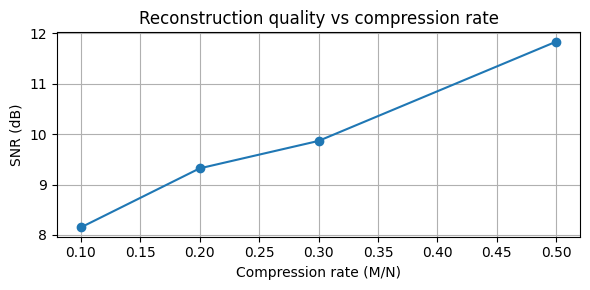

In [12]:
rates_to_test = [0.1, 0.2, 0.3, 0.5]

results = {}
for rate in rates_to_test:
    _tmp_r = tempfile.mkdtemp()
    cs_r = CS(
        folder_audio     = str(Path(file_path).parent),
        folder_saved     = _tmp_r,
        sample_rate      = sample_rate,
        frame_size       = frame_size,
        overlap          = overlap,
        compression_rate = rate,
    )
    idx_r     = cs_r.compress_matrix_1D()
    wins      = cs_r.segment_audio_sliding_window(audio)
    comp_r    = (wins * cs_r.analysis_window)[:, idx_r].astype(np.float32)

    batches = []
    for s in range(0, comp_r.shape[0], cs_r.batch_size):
        batches.append(cs_r._iht_reconstruction_batch(
            comp_r[s:s+cs_r.batch_size], idx_r,
            sparsity=None, max_iter=max_iter, tol=alpha, debias=True))

    rec_r  = cs_r.overlap_add(np.concatenate(batches, axis=0), window=cs_r.analysis_window)
    ml     = min(len(orig), len(rec_r))
    noise_r = orig[:ml] - rec_r[:ml].astype(np.float64)
    snr_r   = 10 * np.log10(np.sum(orig[:ml]**2) / (np.sum(noise_r**2) + 1e-12))
    results[rate] = snr_r
    print(f"rate={rate:.0%}  M={len(idx_r)}  SNR={snr_r:.1f} dB")

plt.figure(figsize=(6, 3))
plt.plot(list(results.keys()), list(results.values()), marker="o")
plt.xlabel("Compression rate (M/N)")
plt.ylabel("SNR (dB)")
plt.title("Reconstruction quality vs compression rate")
plt.grid(True)
plt.tight_layout()
plt.show()